In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

### Quick Data Wrangling to Get Datetime alignment between offline and raman

In [77]:
df_reactor = pd.read_csv(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\raw\DR22-019-Production.csv")
df_reactor['Sample Time'] = pd.to_datetime(df_reactor['Sample Time'])

In [87]:
df = pd.read_csv(r"M:\Zach Hatzenbeller\dr22-019-glucose-lactate.csv")
df_glucose = df[df["Tagname"] == "FER658 GLUCOSE  PV"]
df_lactate = df[df["Tagname"] == "FER658 LACTATE  PV"]
df_glucose['Datetime'] = pd.to_datetime(df_glucose['Datetime'])
df_lactate['Datetime'] = pd.to_datetime(df_lactate['Datetime'])
# df_glucose = df_glucose.filter(["Datetime","Value_1"]).set_index('Datetime')
# df_lactate = df_lactate.filter(["Datetime","Value_1"]).set_index('Datetime')
# date_list = []
# for i in df_reactor['Sample Time']:
#     close_date_1 = df_glucose.iloc[df_glucose.index.get_loc(i,method='nearest')]
#     close_date_2 = df_lactate.iloc[df_lactate.index.get_loc(i,method='nearest')]
#     date_list.append([i, close_date_1[0],close_date_2[0]])

# df_selected = pd.DataFrame(date_list, columns=["Datetime","Glucose","Lactate"])

In [94]:
df_reactor

,Batch,Condition,Day,Sample Time,TCC,VCC,Lact,Osmo,Gluc,Ammonium,IGG,F30 Feed Amount (mL),Glucose Added (mL),Volume,Glucose Raman,Lactate Raman
0,DR22-019-659,PVRIG 200L Batch,0.0,2022-08-16 17:42:00,17.4,17.1,0.34,310.0,7.10,1.76,96.11,513.0,0.0,157100.0,1.00,0.00
1,DR22-019-659,PVRIG 200L Batch,1.0,2022-08-17 09:18:00,26.0,25.5,1.09,291.0,4.64,6.25,295.71,1682.0,252.0,157500.0,4.84,0.67
2,DR22-019-659,PVRIG 200L Batch,2.0,2022-08-18 09:29:00,37.9,37.3,0.18,251.0,1.97,2.12,822.69,3496.0,1398.0,157800.0,2.16,0.37
3,DR22-019-659,PVRIG 200L Batch,3.0,2022-08-19 09:15:00,51.0,50.1,0.04,253.0,2.70,3.20,1462.94,6291.0,2015.0,160300.0,2.17,0.24
4,DR22-019-659,PVRIG 200L Batch,4.0,2022-08-20 09:42:00,48.4,47.7,0.06,263.0,3.18,4.90,2075.45,9055.0,2143.0,163100.0,2.06,0.22
5,DR22-019-659,PVRIG 200L Batch,5.0,2022-08-21 09:35:00,45.4,44.5,0.05,265.0,1.76,5.63,2635.40,11863.0,3177.0,165600.0,0.73,0.10
6,DR22-019-659,PVRIG 200L Batch,6.0,2022-08-22 09:44:00,41.9,41.0,0.12,274.0,2.43,6.35,3175.37,14455.0,3740.0,169200.0,1.13,0.06
7,DR22-019-659,PVRIG 200L Batch,7.0,2022-08-23 09:18:00,38.2,37.3,0.11,278.0,1.59,6.96,3683.67,17107.0,5650.0,172000.0,1.20,0.00
8,DR22-019-659,PVRIG 200L Batch,8.0,2022-08-24 09:27:00,30.5,29.4,0.13,295.0,2.68,7.41,4026.00,19258.0,6560.0,176500.0,1.18,0.00
9,DR22-019-659,PVRIG 200L Batch,9.0,2022-08-25 09:56:00,30.1,28.1,0.10,311.0,1.63,8.70,4566.60,21321.0,8126.0,179500.0,0.87,0.00


### Alpha filter to correct raman measurements based on inaccuracy compared to offline measurements

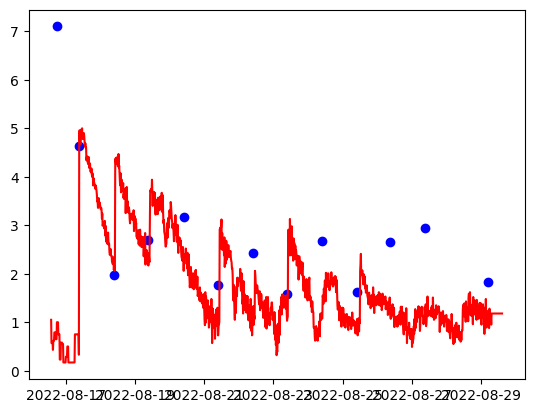

In [97]:
plt.plot(df_reactor["Sample Time"], df_reactor["Gluc"],"bo")
plt.plot(df_glucose["Datetime"], df_glucose["Value_1"], "r-")

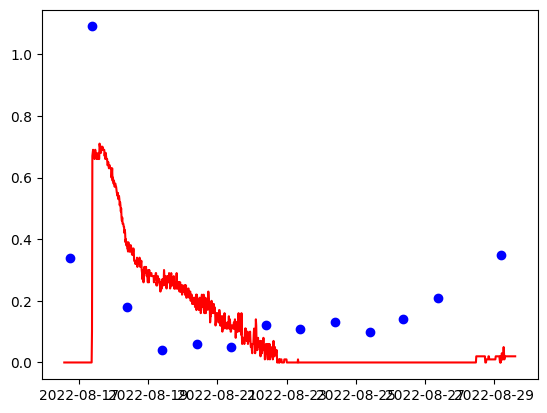

In [145]:
plt.plot(df_reactor["Sample Time"], df_reactor["Lact"],"bo")
plt.plot(df_lactate["Datetime"], df_lactate["Value_1"], "r-")

In [171]:
new_raman = []
k = .2
offline_count = 0
for count, value in enumerate(df_glucose["Value_1"]):
    if df_glucose["Datetime"].iloc[count] >  df_reactor["Sample Time"].iloc[offline_count+1]:
        offline_count += 1
    try:
        xm = df_reactor["Gluc"].iloc[offline_count]
        xk = value
        xkf = df_glucose["Value_1"].iloc[count+1]
        rk = xm - xk
        a = 1 - np.exp(-k*(rk)**2)
        estimate = xkf + a*rk
        new_raman.append(estimate)
    except IndexError:
        estimate = df_glucose["Value_1"].iloc[count]
        new_raman.append(estimate)


Text(0.5, 1.0, 'Raman Correction with alpha = 0.08343289901851259')

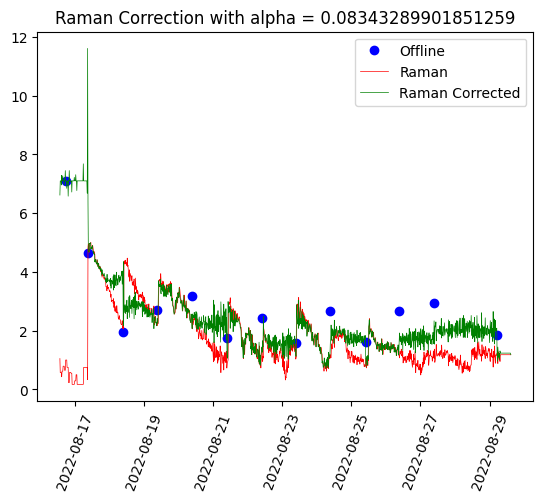

In [172]:
plt.plot(df_reactor["Sample Time"], df_reactor["Gluc"],"bo",markersize=6,label="Offline")
plt.plot(df_glucose["Datetime"], df_glucose["Value_1"], "r-",linewidth=.5,label="Raman")
plt.plot(df_glucose["Datetime"], new_raman, "g-",linewidth=.5,label="Raman Corrected")
plt.legend()
plt.xticks(rotation=70)
plt.title(f"Raman Correction with alpha = {a}")

In [143]:
new_lactate = []
a =.7
offline_count = 0
for count, value in enumerate(df_lactate["Value_1"]):
    if df_lactate["Datetime"].iloc[count] >  df_reactor["Sample Time"].iloc[offline_count+1]:
        offline_count += 1
    try:
        xm = df_reactor["Lact"].iloc[offline_count]
        xk = value
        xkf = df_lactate["Value_1"].iloc[count+1]
        rk = xm - xk
        estimate = xkf + a*rk
        new_lactate.append(estimate)
    except IndexError:
        estimate = df_lactate["Value_1"].iloc[count]
        new_lactate.append(estimate)

Text(0.5, 1.0, 'Raman Correction with alpha = 0.7')

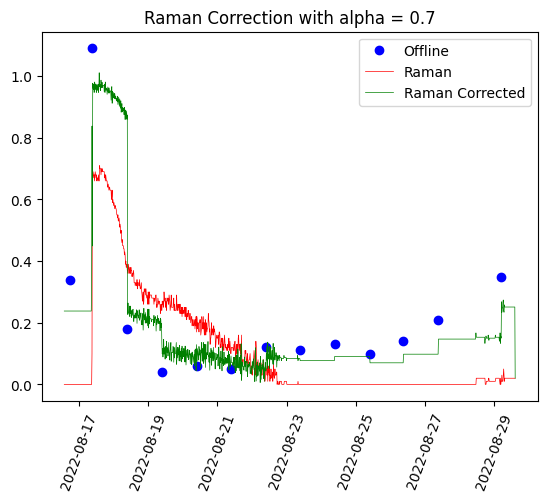

In [144]:
plt.plot(df_reactor["Sample Time"], df_reactor["Lact"],"bo",markersize=6,label="Offline")
plt.plot(df_lactate["Datetime"], df_lactate["Value_1"], "r-",linewidth=.5,label="Raman")
plt.plot(df_lactate["Datetime"], new_lactate, "g-",linewidth=.5,label="Raman Corrected")
plt.legend()
plt.xticks(rotation=70)
plt.title(f"Raman Correction with alpha = {a}")

In [209]:
A = np.loadtxt(r"M:\Zach Hatzenbeller\A_Matrix.csv", delimiter=',')
B = np.loadtxt(r"M:\Zach Hatzenbeller\B_Matrix.csv", delimiter=',')
A = np.loadtxt(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\current\Model 1\A_Matrix.csv", delimiter=',')
B = np.loadtxt(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\current\Model 1\B_Matrix.csv", delimiter=',')
A

array([[ 0.17264784,  1.06940059, -1.50972642,  0.75760782,  0.13575628,
         1.31004444, -0.89115624],
       [-0.51080399,  1.45561969, -0.67801996,  0.64684945,  0.10405755,
         0.21453459, -0.43463182],
       [-0.15452383,  0.37330525,  0.59630057, -0.08362356, -0.22447047,
         0.79425149, -0.2210952 ],
       [-0.20456495,  0.38913968,  0.03494017,  0.70588691, -0.18623694,
         0.46638787, -0.04583352],
       [ 0.54029245, -0.93476303, -0.64648809,  1.50058616,  0.50254074,
        -0.61738369,  0.16788006],
       [-0.20897669,  0.20154088,  0.50169125, -0.12979862, -0.1382704 ,
         0.67312626,  0.16952764],
       [ 0.14366856, -0.13138691, -0.43026375,  0.17201091,  0.1401078 ,
         0.18719163,  0.86998576]])

In [213]:
import scipy
logA = scipy.linalg.logm(A)
scipy.linalg.expm(logA)

array([[ 0.17264784,  1.06940059, -1.50972642,  0.75760782,  0.13575628,
         1.31004444, -0.89115624],
       [-0.51080399,  1.45561969, -0.67801996,  0.64684945,  0.10405755,
         0.21453459, -0.43463182],
       [-0.15452383,  0.37330525,  0.59630057, -0.08362356, -0.22447047,
         0.79425149, -0.2210952 ],
       [-0.20456495,  0.38913968,  0.03494017,  0.70588691, -0.18623694,
         0.46638787, -0.04583352],
       [ 0.54029245, -0.93476303, -0.64648809,  1.50058616,  0.50254074,
        -0.61738369,  0.16788006],
       [-0.20897669,  0.20154088,  0.50169125, -0.12979862, -0.1382704 ,
         0.67312626,  0.16952764],
       [ 0.14366856, -0.13138691, -0.43026375,  0.17201091,  0.1401078 ,
         0.18719163,  0.86998576]])

#### Growth rate and glucose consumption estimation based on ambr data

In [283]:
DISCARD = [
    "AR21-048-001",
    "AR21-048-003",
    "AR21-048-009",
    "AR22-001-001",
]

In [347]:
df = pd.read_excel(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\raw\AR22-001-Kalman-Filter.xlsx")
df["Linearized"] = None
df = df[~df["Batch"].str.contains("|".join(DISCARD))]
df['Sample Time'] = pd.to_datetime(df['Sample Time'])
df

,Unnamed: 0,Batch,Condition,Day,Sample Time,TCC,VCC,Lact,Osmo,Gluc,...,Daily_Feed_Normalized,Daily_Glucose_Normalized,Daily_Feed,Daily_Glucose,Glucose_Consumption,Glucose Added(g),Glucose in culture (g),Total Glucose in Culture (g),Glucose Consumption (g/L/day),Linearized
0,0,AR22-001-002,CSFR: 0.00023 to 0.00037,0,2022-01-19 13:32:00,27.5054,27.4820,0.68,332.0,6.96,...,0.006400,0.000000,1.15,0.0,NaN,0.00,1.250573,6.960000,NaN,None
1,21,AR22-001-002,CSFR: 0.00023 to 0.00037,1,2022-01-20 09:00:00,41.4791,41.2412,0.99,290.0,2.57,...,0.015526,0.000000,2.81,0.0,4.390000,0.00,0.465144,2.570000,4.390000,None
2,42,AR22-001-002,CSFR: 0.00023 to 0.00037,2,2022-01-21 09:26:00,62.9395,62.5703,0.04,266.0,0.11,...,0.025587,0.014483,4.77,2.7,2.460000,1.08,0.020506,5.903370,2.460000,None
3,63,AR22-001-002,CSFR: 0.00023 to 0.00037,3,2022-01-22 09:41:00,59.3242,58.5793,0.08,286.0,3.92,...,0.027835,0.000000,5.29,0.0,1.983370,0.00,0.744996,3.920000,1.983370,None
4,84,AR22-001-002,CSFR: 0.00023 to 0.00037,4,2022-01-23 09:10:00,59.6531,57.0960,0.08,277.0,1.02,...,0.029083,0.012246,5.70,2.4,2.900000,0.96,0.199910,5.918209,2.900000,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,184,AR22-001-019,CSFR: 0.00037 to 0.0002 to 0.00023,8,2022-01-27 07:53:00,42.7908,39.7553,0.16,305.0,1.45,...,0.008366,0.009182,1.64,1.8,3.424958,0.72,0.284243,5.122907,3.424958,None
230,205,AR22-001-019,CSFR: 0.00037 to 0.0002 to 0.00023,9,2022-01-28 06:10:00,43.9049,41.3166,0.08,312.0,2.14,...,0.008635,0.007070,1.71,1.4,2.982907,0.56,0.423763,4.967997,2.982907,None
231,226,AR22-001-019,CSFR: 0.00037 to 0.0002 to 0.00023,10,2022-01-29 07:50:00,40.1869,36.4546,0.17,324.0,2.31,...,0.008054,0.006503,1.61,1.3,2.657997,0.52,0.461769,4.911301,2.657997,None
232,247,AR22-001-019,CSFR: 0.00037 to 0.0002 to 0.00023,11,2022-01-30 07:34:00,36.0542,30.7996,0.21,338.0,2.91,...,0.007377,0.000000,1.47,0.0,2.001301,0.00,0.579905,2.910000,2.001301,None


In [348]:
batch_grouped = df.groupby("Batch", group_keys=False)
rate_dict = {}
rate_data = []
for _, group in batch_grouped:
    linearized_vcc = []
    for index in range(len(group["VCC"])-1):
        linearized_data = np.log(group["VCC"].iloc[index+1]/group["VCC"].iloc[index])
        linearized_vcc.append(linearized_data)
    linearized_vcc.append(0)
    group["Linearized"] = linearized_vcc
    rate_data.append(group)
rate_data = pd.concat(rate_data)
rate_data.head()

,Unnamed: 0,Batch,Condition,Day,Sample Time,TCC,VCC,Lact,Osmo,Gluc,...,Daily_Feed_Normalized,Daily_Glucose_Normalized,Daily_Feed,Daily_Glucose,Glucose_Consumption,Glucose Added(g),Glucose in culture (g),Total Glucose in Culture (g),Glucose Consumption (g/L/day),Linearized
0,0,AR22-001-002,CSFR: 0.00023 to 0.00037,0,2022-01-19 13:32:00,27.5054,27.4820,0.68,332.0,6.96,...,0.006400,0.000000,1.15,0.0,NaN,0.00,1.250573,6.960000,NaN,0.405907
1,21,AR22-001-002,CSFR: 0.00023 to 0.00037,1,2022-01-20 09:00:00,41.4791,41.2412,0.99,290.0,2.57,...,0.015526,0.000000,2.81,0.0,4.39000,0.00,0.465144,2.570000,4.39000,0.416853
2,42,AR22-001-002,CSFR: 0.00023 to 0.00037,2,2022-01-21 09:26:00,62.9395,62.5703,0.04,266.0,0.11,...,0.025587,0.014483,4.77,2.7,2.46000,1.08,0.020506,5.903370,2.46000,-0.065909
3,63,AR22-001-002,CSFR: 0.00023 to 0.00037,3,2022-01-22 09:41:00,59.3242,58.5793,0.08,286.0,3.92,...,0.027835,0.000000,5.29,0.0,1.98337,0.00,0.744996,3.920000,1.98337,-0.025647
4,84,AR22-001-002,CSFR: 0.00023 to 0.00037,4,2022-01-23 09:10:00,59.6531,57.0960,0.08,277.0,1.02,...,0.029083,0.012246,5.70,2.4,2.90000,0.96,0.199910,5.918209,2.90000,-0.078257


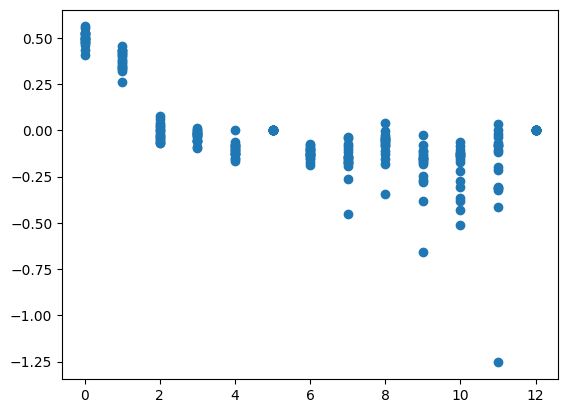

In [349]:
plt.scatter(rate_data["Day"], rate_data["Linearized"])

In [350]:
averaged_rates = rate_data[rate_data["Linearized"] > -0.2].groupby("Day")["Linearized"].mean()

In [351]:
averaged_rates

Day
0     4.964132e-01
1     3.792567e-01
2    -9.987021e-03
3    -3.182283e-02
4    -1.047117e-01
5     1.652999e-15
6    -1.237796e-01
7    -1.287648e-01
8    -6.689768e-02
9    -1.321619e-01
10   -1.232589e-01
11   -5.600884e-02
12    0.000000e+00
Name: Linearized, dtype: float64

In [352]:
np.array(averaged_rates)

array([ 4.96413155e-01,  3.79256662e-01, -9.98702134e-03, -3.18228280e-02,
       -1.04711726e-01,  1.65299873e-15, -1.23779627e-01, -1.28764833e-01,
       -6.68976847e-02, -1.32161932e-01, -1.23258854e-01, -5.60088378e-02,
        0.00000000e+00])

In [353]:
x = np.arange(0,len(averaged_rates),1)
rate_fit = np.polyfit(x, np.array(averaged_rates), deg=3)
rate_fit

array([-0.0010862 ,  0.02961814, -0.24371154,  0.49726371])

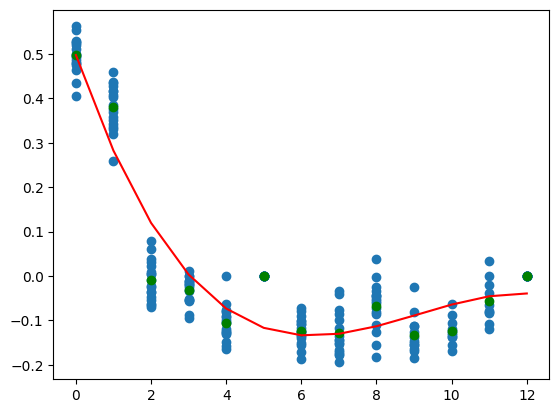

In [354]:
plt.plot(x, np.array(averaged_rates),"go")
plt.plot(x, np.polyval(rate_fit,x),"r")
plt.scatter(rate_data[rate_data["Linearized"] > -0.2]["Day"], rate_data[rate_data["Linearized"] > -0.2]["Linearized"])

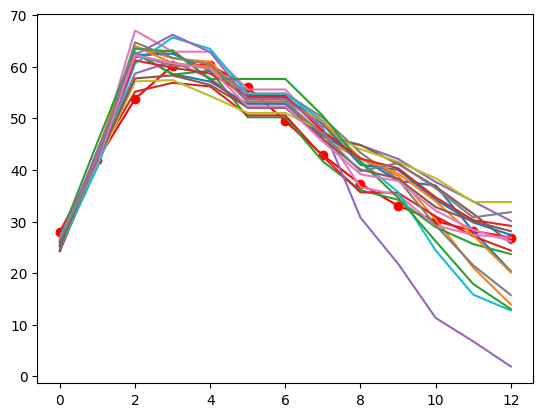

In [355]:
ivcc = 28
sim_data = []
for i in range(13):
    if i == 0:
        xv = ivcc
        sim_data.append(xv)
    else:
        xv = sim_data[i-1] * np.polyval(rate_fit,i-1) + sim_data[i-1]
        sim_data.append(xv)
plt.plot(np.arange(0,13,1),sim_data,"ro-")
for _, group in batch_grouped:
    plt.plot(group["Day"], group["VCC"])

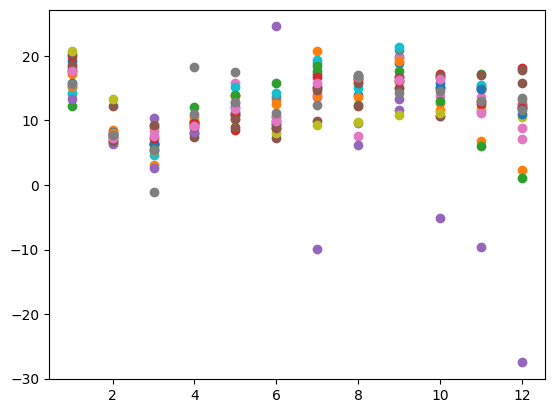

In [359]:
for _, group in batch_grouped:
    plt.plot(group["Day"], (group["Glucose_Consumption"]*1e3*(group["Volume"]/1000))/group["VCC"],"o")

In [363]:
rate_data["Glucose_Consump (ng/cell/day)"] = (rate_data["Glucose_Consumption"]*1e3*(rate_data["Volume"]/1000))/rate_data["VCC"]

In [372]:
glucose_rates = rate_data[rate_data["Glucose_Consump (ng/cell/day)"] > 5].groupby("Day")["Glucose_Consump (ng/cell/day)"].mean()
glucose_rates

Day
1     16.858741
2      8.136342
3      7.372398
4      9.855355
5     12.315145
6     11.507559
7     15.501932
8     13.849160
9     16.669307
10    14.344242
11    13.089461
12    12.579615
Name: Glucose_Consump (ng/cell/day), dtype: float64

In [370]:
x = np.arange(0,len(glucose_rates),1)
glucose_fit = np.polyfit(x, np.array(glucose_rates), deg=1)
glucose_fit

array([ 0.31110759, 10.96217962])

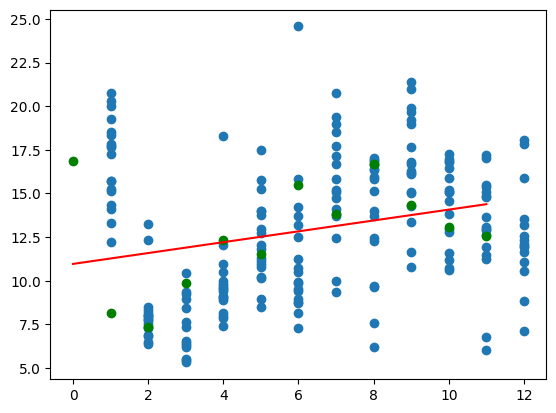

In [373]:
plt.plot(x, np.array(glucose_rates),"go")
plt.plot(x, np.polyval(glucose_fit,x),"r")
plt.scatter(rate_data[rate_data["Glucose_Consump (ng/cell/day)"] > 5]["Day"], rate_data[rate_data["Glucose_Consump (ng/cell/day)"] > 5]["Glucose_Consump (ng/cell/day)"])

In [387]:
a = 9
b = 32
def a_b_sum(a,b):
    if b < 0:
        return 0
    elif b == 0:
        return a
    else:
        return 1 + a_b_sum(a,b-1)

a_b_sum(a,b)

41

In [505]:
def average(A):
    if len(A) == 0:
        return 0
    elif len(A) == 1:
        return A[0]
    elif len(A) > 1:
        size = len(A)
        return (A[0]  + ((size-1) * average(A[1:])))/size

A = [5,6,7,8]
average(A)

[5, 6, 7, 8]
4
[6, 7, 8]
3
[7, 8]
2
[8]


6.5